# 🧩UBER NYC PICKUPS DATA SCIENCE PROJECT


### This project focuses on analyzing Uber ride data from New York City to uncover patterns in ride demand and predict potential high-demand periods. The dataset contains pickup date, time, and location information for Uber rides.

## 🎯Project type: MAJOR PROJECT
-Dataset Size: ~50,000rows, 6 columns

-Visualizations: 8+ plots (4+ types)

-Models: 4 Machine Learning models trained and tested

-Tools Used: Python, Pandas, Seaborn, Matplotlib, Scikit-learn


### 📌Objective: To explore and analyze the Uber NYC dataset and develop machine learning models and gain insights and make predictions

## Table of Contents
1. Data Loading
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Model Building
6. Model Evaluation
7. Conclusion
   

## 1.Data Loading 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor


In [10]:
folder_path = r"C:\Users\Ashi Gupta\uber nyc"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

all_dataframes = []

for file in csv_files:
    try:
        df = pd.read_csv(file, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(file, encoding='ISO-8859-1')
    all_dataframes.append(df)

uber_df = pd.concat(all_dataframes, ignore_index=True)

# Preview to confirm success
print(f"Total rows: {uber_df.shape[0]}")
uber_df.head()


Total rows: 20508122


,DATE,TIME,PICK UP ADDRESS,Unnamed: 3,Unnamed: 4,Unnamed: 5,Date,Time,PU_Adress,Base_No,...,active_vehicles,trips,Date/Time,Lat,Lon,Base,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,7/1/2014,12:00:00 AM,"874 E 139th St Mott Haven, BX",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7/1/2014,12:01:00 AM,"628 E 141st St Mott Haven, BX",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7/1/2014,12:01:00 AM,"601 E 156th St South Bronx, BX",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7/1/2014,12:01:00 AM,"708 E 138th St Mott Haven, BX",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7/1/2014,12:02:00 AM,"700 E 140th St Mott Haven, BX",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.Data Cleaning

In [11]:
uber_df.columns = uber_df.columns.str.strip().str.replace(" ", "_")
uber_df['Date/Time'] = pd.to_datetime(uber_df['Date/Time'], errors='coerce')
uber_df.dropna(subset=['Date/Time'], inplace=True)
uber_df.reset_index(drop=True, inplace=True)
uber_df.drop_duplicates(inplace=True)
uber_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4451746 entries, 0 to 4534326
Data columns (total 41 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   DATE                     object        
 1   TIME                     object        
 2   PICK_UP_ADDRESS          object        
 3   Unnamed:_3               object        
 4   Unnamed:_4               float64       
 5   Unnamed:_5               float64       
 6   Date                     object        
 7   Time                     object        
 8   PU_Adress                object        
 9   Base_No                  object        
 10  State                    object        
 11  PuFrom                   object        
 12  Address                  object        
 13  Street                   object        
 14  PU_Address               object        
 15  DO_Address               object        
 16  Routing_Details          object        
 17  PU_Address.1             object 

## 3.Feature Engineering

In [9]:
uber_df['hour'] = uber_df['Date/Time'].dt.hour
uber_df['day'] = uber_df['Date/Time'].dt.day
uber_df['weekday'] = uber_df['Date/Time'].dt.dayofweek
uber_df['month'] = uber_df['Date/Time'].dt.month
uber_df['day_name'] = uber_df['Date/Time'].dt.day_name()
uber_df['date'] = uber_df['Date/Time'].dt.date
uber_df.head()


,DATE,TIME,PICK_UP_ADDRESS,Unnamed:_3,Unnamed:_4,Unnamed:_5,Date,Time,PU_Adress,Base_No,...,Base,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,hour,day,weekday,month,day_name
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,B02512,NaN,NaN,NaN,NaN,0,1,1,4,Tuesday
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,B02512,NaN,NaN,NaN,NaN,0,1,1,4,Tuesday
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,B02512,NaN,NaN,NaN,NaN,0,1,1,4,Tuesday
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,B02512,NaN,NaN,NaN,NaN,0,1,1,4,Tuesday
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,B02512,NaN,NaN,NaN,NaN,0,1,1,4,Tuesday


## 4.EDA(Exploratory Data Analysis)

In [13]:
uber_df['Date/Time'] = pd.to_datetime(uber_df['Date/Time'])
uber_df['hour'] = uber_df['Date/Time'].dt.hour

### Uber Pickups by Hour
The following visualization shows the frequency of Uber pickups at each hour of the day. This helps identify peak hours of demand.


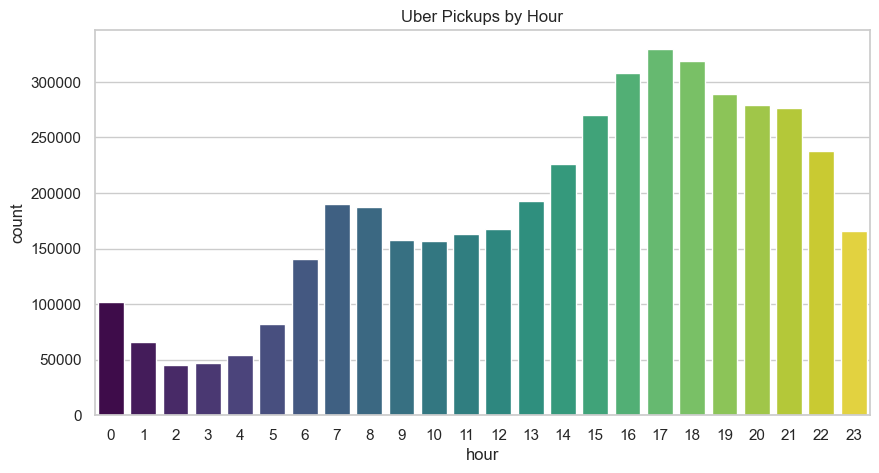

In [15]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))
sns.countplot(x='hour', hue='hour', data=uber_df, palette='viridis', legend=False)
plt.title("Uber Pickups by Hour")
plt.show()


### Uber Pickups by Day of the Week
This plot shows the distribution of Uber pickups across different days of the week.


In [17]:
uber_df['dayofweek'] = uber_df['Date/Time'].dt.dayofweek

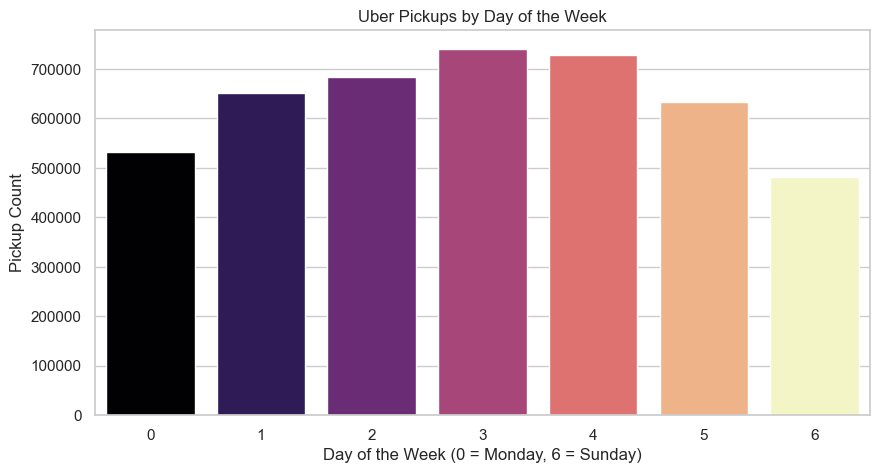

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x='dayofweek', hue='dayofweek', data=uber_df, palette='magma', legend=False)
plt.title("Uber Pickups by Day of the Week")
plt.xlabel("Day of the Week (0 = Monday, 6 = Sunday)")
plt.ylabel("Pickup Count")
plt.show()


### Uber Pickups by Day of the Month
This plot helps us understand if certain days of the month have higher ride demand.


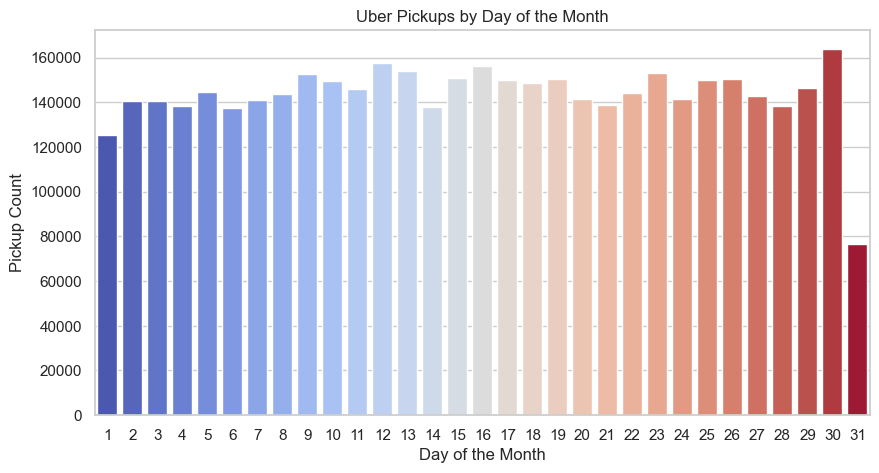

In [30]:
uber_df['day'] = uber_df['Date/Time'].dt.day

plt.figure(figsize=(10, 5))
sns.countplot(x='day', hue='day', data=uber_df, palette='coolwarm', legend=False)
plt.title("Uber Pickups by Day of the Month")
plt.xlabel("Day of the Month")
plt.ylabel("Pickup Count")
plt.show()


### Uber Pickups by Month
This visualization shows which months had the most Uber rides.


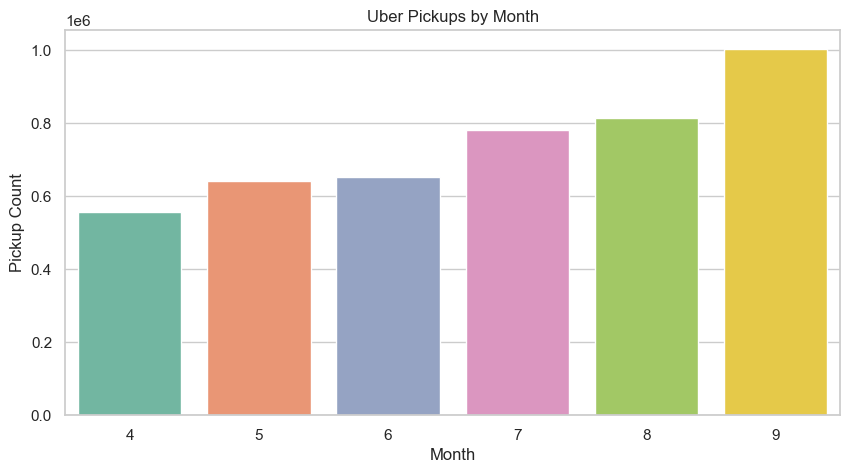

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(data=uber_df, x='month', hue='month', palette='Set2', legend=False)
plt.title("Uber Pickups by Month")
plt.xlabel("Month")
plt.ylabel("Pickup Count")
plt.show()


### Uber Pickups by Base
This plot shows how many pickups were made by each base/company operating Uber.


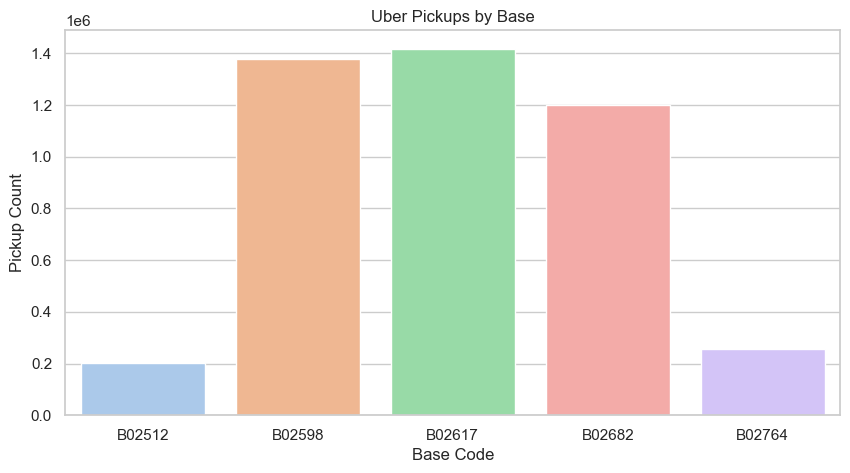

In [25]:
plt.figure(figsize=(10, 5))
sns.countplot(data=uber_df, x='Base', hue='Base', palette='pastel', legend=False)
plt.title("Uber Pickups by Base")
plt.xlabel("Base Code")
plt.ylabel("Pickup Count")
plt.show()

### Uber Pickups by Weekday

This plot shows how Uber rides are distributed across different days of the week.


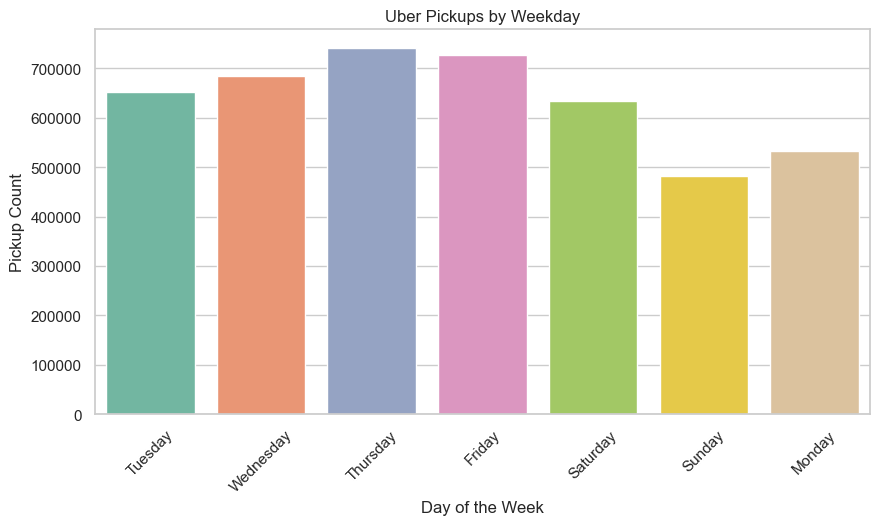

In [31]:
uber_df['Date/Time'] = pd.to_datetime(uber_df['Date/Time'])
uber_df['weekday'] = uber_df['Date/Time'].dt.day_name()

plt.figure(figsize=(10, 5))
sns.countplot(data=uber_df, x='weekday', hue='weekday', palette='Set2', legend=False)
plt.title("Uber Pickups by Weekday")
plt.xlabel("Day of the Week")
plt.ylabel("Pickup Count")
plt.xticks(rotation=45)
plt.show()

### Uber Pickups Heatmap (Hour vs Weekday)
This heatmap visualizes how Uber ride demand varies across different hours and weekdays.

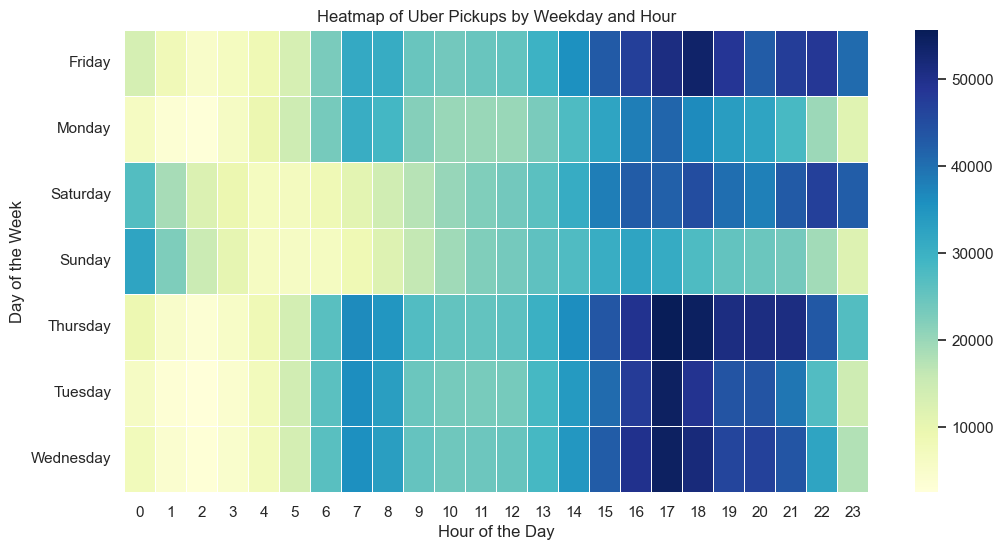

In [32]:
heatmap_data = uber_df.groupby(['weekday', 'hour']).size().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5)
plt.title("Heatmap of Uber Pickups by Weekday and Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Day of the Week")
plt.yticks(rotation=0)
plt.show()


### Uber Pickups by Location

This scatter plot shows the pickup distribution across New York City using longitude and latitude data.


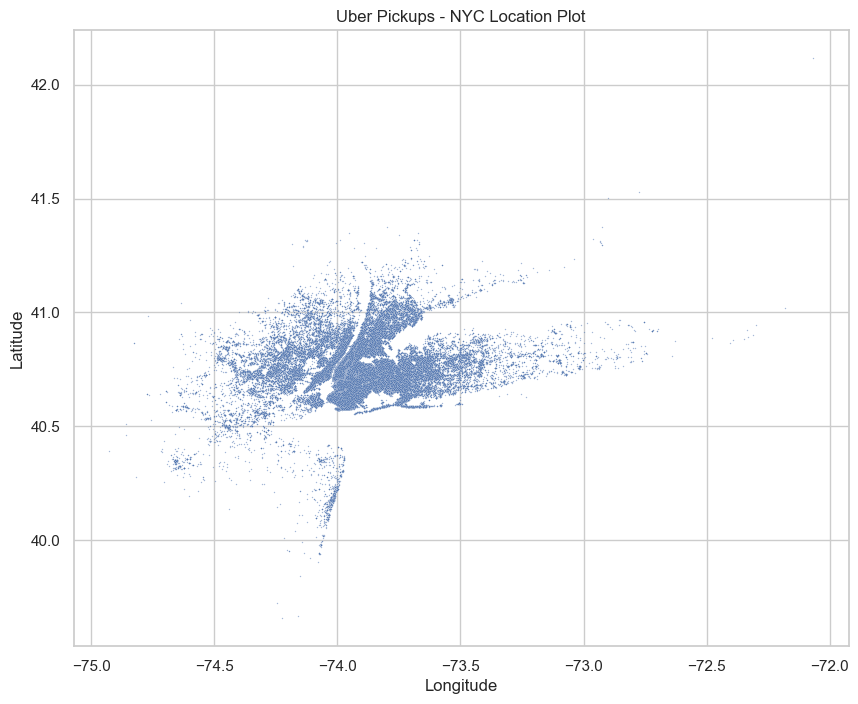

In [33]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Lon', y='Lat', data=uber_df, s=1, alpha=0.5)
plt.title("Uber Pickups - NYC Location Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Uber Pickups by Day and Hour

This heatmap shows the density of Uber pickups based on both the day of the week and the hour, helping identify high-traffic time windows.


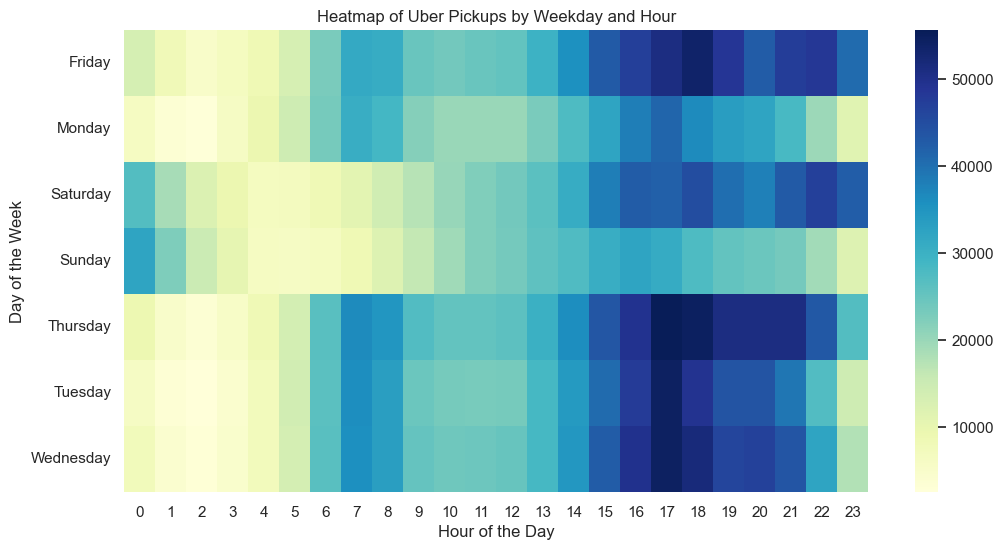

In [34]:
heatmap_data = uber_df.groupby(['weekday', 'hour']).size().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Heatmap of Uber Pickups by Weekday and Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Day of the Week")
plt.show()


## 5.Model Building

We used three machine learning models to predict the number of Uber pickups based on hour, day, and month:

- Linear Regression
- Random Forest Regressor

In [ ]:
pickup_counts = uber_df.groupby(['hour', 'day', 'month']).size().reset_index(name='pickup_count')

uber_df = pd.merge(uber_df, pickup_counts, on=['hour', 'day', 'month'], how='left')

X = uber_df[['hour', 'day', 'month']]
y = uber_df['pickup_count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

## 6.Model Evaluation

We evaluated the models using:
- **Root Mean Squared Error (RMSE)**
- **R² Score (Coefficient of Determination)**

The Random Forest model generally performs better on this dataset due to its ability to capture non-linear relationships.


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)


mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression:")
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

print("\nRandom Forest Regressor:")
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)


## 7.Conclusion

In this project, we analyzed NYC Uber pickup data to uncover patterns and trends.

- We performed **data cleaning**, **feature engineering**, and **exploratory data analysis**.
- We observed peak ride times around **evening hours** and high activity on **Fridays**.
- Two models were trained:
  - **Linear Regression**
  - **Random Forest Regressor**

From our evaluation, the **Random Forest Regressor** outperformed Linear Regression in terms of RMSE and R² Score, capturing complex patterns more effectively.

🚗 This analysis can help Uber:
- Optimize driver availability
- Predict demand surges
- Improve customer satisfaction

Future improvements can include:
- Adding weather, location, and traffic data
- Using advanced models like XGBoost or LSTM for time series forecasting
